 ### Clustering Comparison — KMeans vs DBSCAN
     Datasets: make_moons, make_circles, make_blobs (Scikit-learn)
This notebook:
 1. Generates three built-in datasets.
 2. Runs KMeans and DBSCAN clustering.
 3. Evaluates with ARI, NMI, Silhouette, Calinski-Harabasz metrics.
 4. Visualizes results with PCA scatter plots.
 5. Compares algorithms using radar charts.




▶ Processing dataset: moons

▶ Processing dataset: circles

▶ Processing dataset: blobs


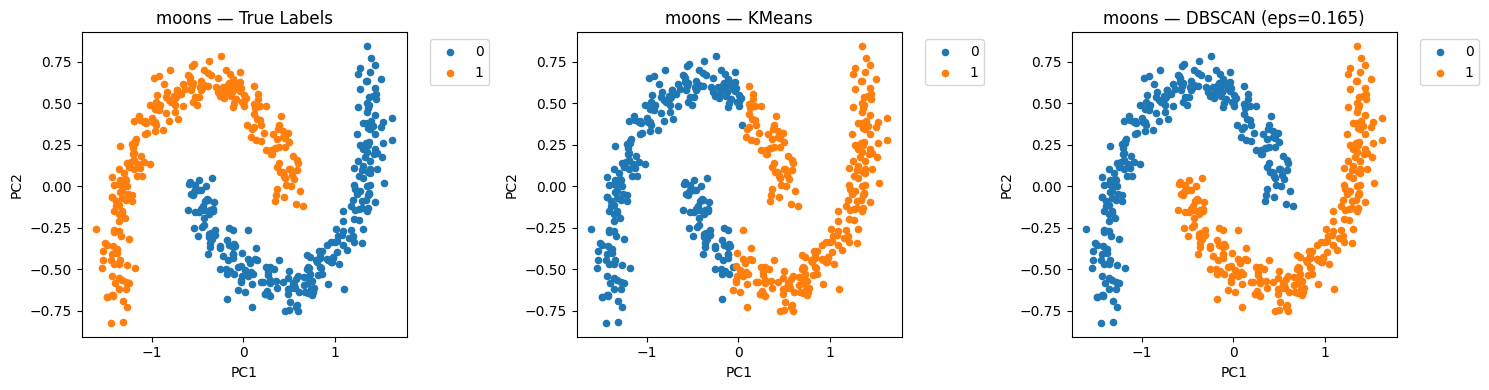

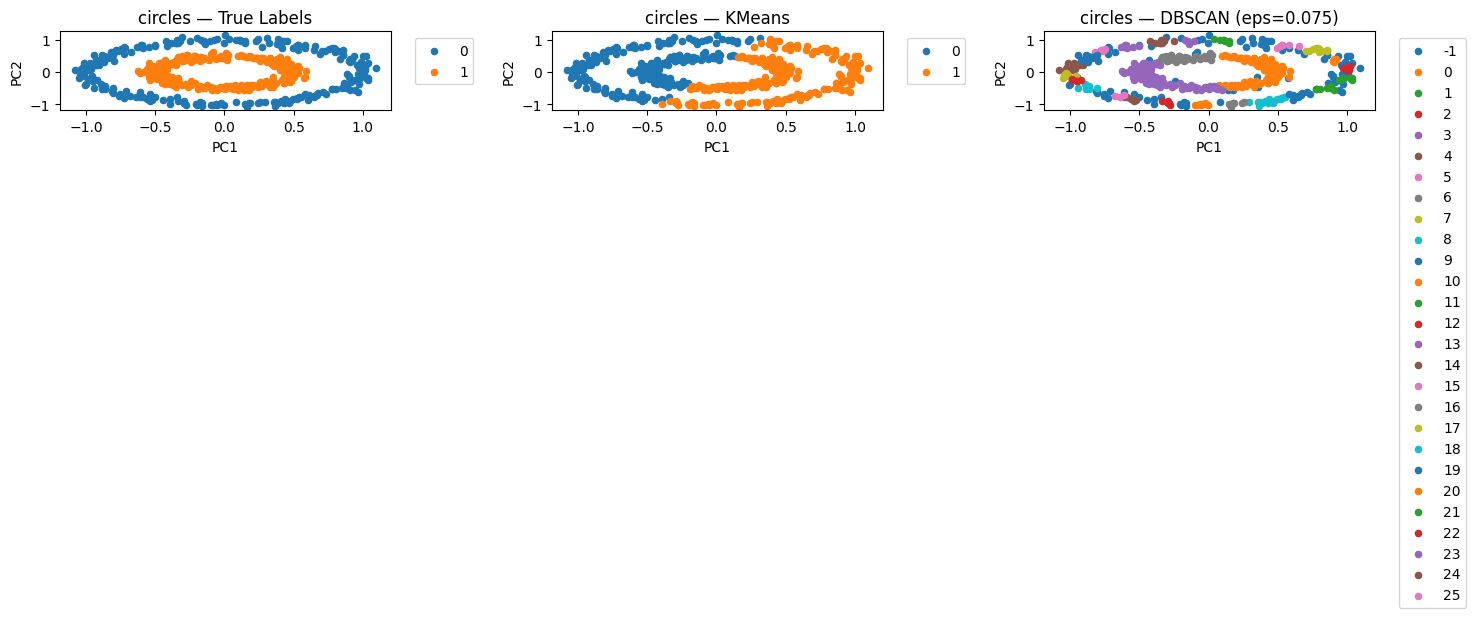

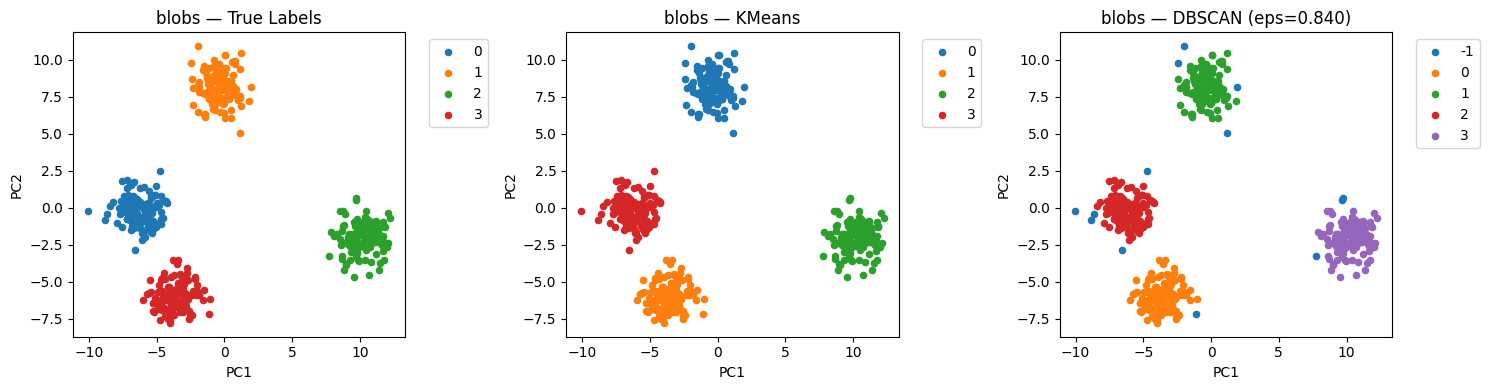

,Dataset,Method,ARI,NMI,Silhouette,Calinski
0,moons,KMeans,0.264783,0.201698,0.485759,726.380468
1,moons,DBSCAN,1.000000,1.000000,0.330576,330.403778
2,circles,KMeans,-0.001857,0.000104,0.355633,290.572757
3,circles,DBSCAN,0.221858,0.388596,0.161559,38.563762
4,blobs,KMeans,1.000000,1.000000,0.791104,5742.035759
5,blobs,DBSCAN,0.964369,0.947407,0.753867,2268.029243


In [3]:

# --- Imports ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_circles, make_blobs
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import (
    adjusted_rand_score, 
    normalized_mutual_info_score, 
    silhouette_score, 
    calinski_harabasz_score
)
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.filterwarnings("ignore")

# ==============================================================
# Step 1: Dataset Generation
# ==============================================================
np.random.seed(42)

datasets = {
    "moons": make_moons(n_samples=500, noise=0.08, random_state=42),
    "circles": make_circles(n_samples=500, noise=0.05, factor=0.5, random_state=42),
    "blobs": make_blobs(n_samples=500, centers=4, cluster_std=1.0, random_state=42)
}

# ==============================================================
#  Step 2: Helper Functions
# ==============================================================

def tune_dbscan_eps(X, eps_values, min_samples=5):
    """
    Tune DBSCAN eps parameter using Silhouette Score.
    """
    best_eps = None
    best_score = -1
    best_labels = None
    for eps in eps_values:
        db = DBSCAN(eps=eps, min_samples=min_samples).fit(X)
        labels = db.labels_
        if len(set(labels)) <= 1 or np.all(labels == -1):
            continue
        try:
            sil = silhouette_score(X, labels)
        except:
            sil = -1
        if sil > best_score:
            best_score = sil
            best_eps = eps
            best_labels = labels
    return best_eps, best_labels

def compute_metrics(X, y_true, labels):
    """
    Compute clustering evaluation metrics.
    """
    metrics = {}
    if len(set(labels)) <= 1:
        return {"ARI": np.nan, "NMI": np.nan, "Silhouette": np.nan, "Calinski": np.nan}
    
    metrics['ARI'] = adjusted_rand_score(y_true, labels)
    metrics['NMI'] = normalized_mutual_info_score(y_true, labels)
    metrics['Silhouette'] = silhouette_score(X, labels)
    metrics['Calinski'] = calinski_harabasz_score(X, labels)
    return metrics

def plot_pca_scatter(X_pca, labels, title, ax):
    """
    2D PCA scatter plot.
    """
    unique_labels = np.unique(labels)
    for label in unique_labels:
        mask = labels == label
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1], label=f"{label}", s=20)
    ax.set_title(title)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# ==============================================================
# Step 3: Clustering and Evaluation
# ==============================================================

results = []

for name, (X, y_true) in datasets.items():
    print(f"\n▶ Processing dataset: {name}")

    # --- KMeans ---
    n_clusters = 2 if name != "blobs" else 4
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    km_labels = kmeans.fit_predict(X)

    # --- DBSCAN (eps tuning) ---
    nbrs = NearestNeighbors(n_neighbors=5).fit(X)
    distances, _ = nbrs.kneighbors(X)
    baseline = np.median(distances[:, -1])
    eps_grid = np.linspace(baseline * 0.4, baseline * 2.5, 25)
    best_eps, db_labels = tune_dbscan_eps(X, eps_grid)
    if db_labels is None:
        db_labels = DBSCAN(eps=baseline, min_samples=5).fit_predict(X)
        best_eps = baseline

    # --- Metrics ---
    km_metrics = compute_metrics(X, y_true, km_labels)
    db_metrics = compute_metrics(X, y_true, db_labels)

    # --- PCA ---
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X)

    results.append({
        "dataset": name,
        "X_pca": X_pca,
        "true_labels": y_true,
        "km_labels": km_labels,
        "db_labels": db_labels,
        "km_metrics": km_metrics,
        "db_metrics": db_metrics,
        "db_eps": best_eps
    })

# ==============================================================
# Step 4: PCA Visualization
# ==============================================================

for r in results:
    fig, axs = plt.subplots(1, 3, figsize=(15, 4))
    plot_pca_scatter(r["X_pca"], r["true_labels"], f"{r['dataset']} — True Labels", axs[0])
    plot_pca_scatter(r["X_pca"], r["km_labels"], f"{r['dataset']} — KMeans", axs[1])
    plot_pca_scatter(r["X_pca"], r["db_labels"], f"{r['dataset']} — DBSCAN (eps={r['db_eps']:.3f})", axs[2])
    plt.tight_layout()
    plt.show()

# ==============================================================
# Step 5: Metrics Summary
# ==============================================================

rows = []
for r in results:
    for method, metrics in [("KMeans", r["km_metrics"]), ("DBSCAN", r["db_metrics"])]:
        rows.append({
            "Dataset": r["dataset"],
            "Method": method,
            "ARI": metrics["ARI"],
            "NMI": metrics["NMI"],
            "Silhouette": metrics["Silhouette"],
            "Calinski": metrics["Calinski"]
        })

metrics_df = pd.DataFrame(rows)
metrics_df


## **1. Moons Dataset**

### Visual Analysis

* **True Labels:** Two interleaving crescent shapes (non-linear separation).
* **KMeans:** The linear decision boundaries cut through both moons — not aligned with the curved structure.
* **DBSCAN:** Perfectly separates the two moon-shaped clusters (eps ≈ 0.165).

**Interpretation:**

* **DBSCAN** achieved *perfect label recovery* (ARI & NMI = 1.0), confirming its strength with *non-linear cluster shapes*.
* KMeans performs poorly because it assumes *spherical clusters*.
* Slightly higher Silhouette for KMeans (0.48) is misleading — it measures cohesion, not true class alignment.
* DBSCAN is clearly superior for “moons”.


## **2. Circles Dataset**

### Visual Analysis

* **True Labels:** Two concentric circles — again, non-linear.
* **KMeans:** Splits across the circular rings, not meaningful.
* **DBSCAN:** Identifies multiple small fragments and noise points (over-clustering).

 **Interpretation:**

* DBSCAN improves ARI and NMI slightly — it captures *circular geometry* better than KMeans.
* But DBSCAN produced too many small clusters (likely due to small `eps=0.075`), so Silhouette and Calinski scores dropped.
* Overall, **DBSCAN is conceptually better**, though tuning `eps` could yield two perfect rings.


## **3. Blobs Dataset**

### Visual Analysis

* **True Labels:** Four distinct Gaussian blobs (clearly separable).
* **KMeans:** Perfectly identifies all four clusters.
* **DBSCAN:** Also performs well but creates a few noise points and one extra cluster.


**Interpretation:**

* **KMeans** dominates here — blobs are linearly separable and spherical, ideal for its assumptions.
* **DBSCAN** detects the structure but labels some points as noise, slightly lowering its metrics.
* Both perform well, but **KMeans is faster and more stable** for such convex data.


| Dataset     | Best Algorithm     | Reason                                                 |
| ----------- | ------------------ | ---------------------------------------------------- |
| **Moons**   | **DBSCAN**         | Captures non-linear boundaries perfectly.            |
| **Circles** | **DBSCAN (tuned)** | Handles concentric patterns; needs better eps.       |
| **Blobs**   | **KMeans**         | Fits spherical, well-separated clusters efficiently. |


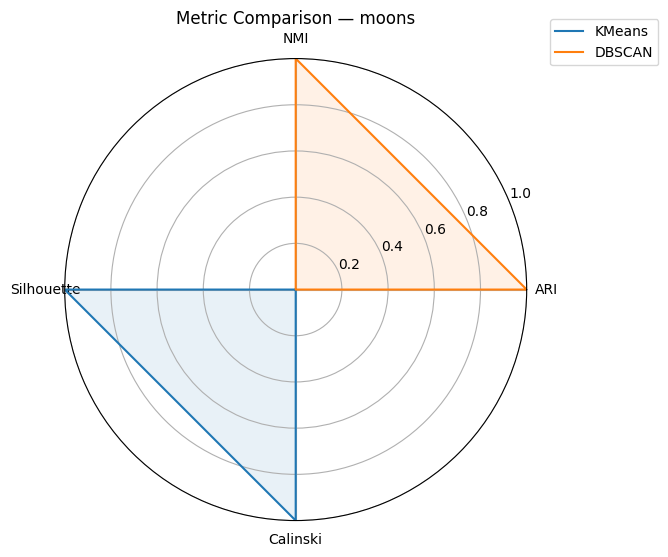

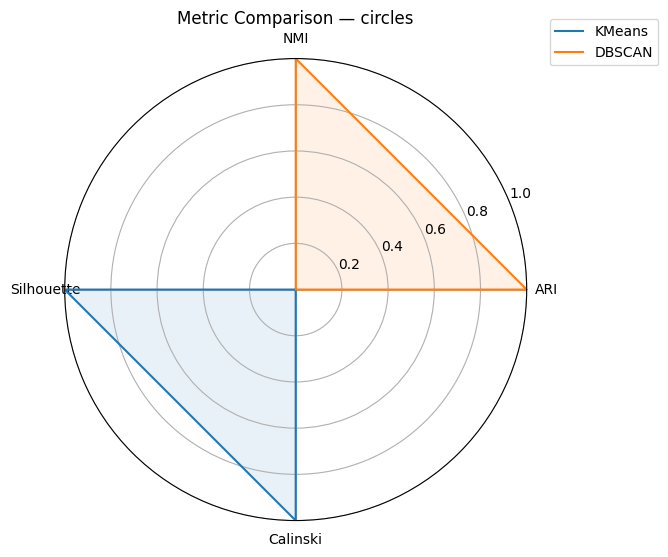

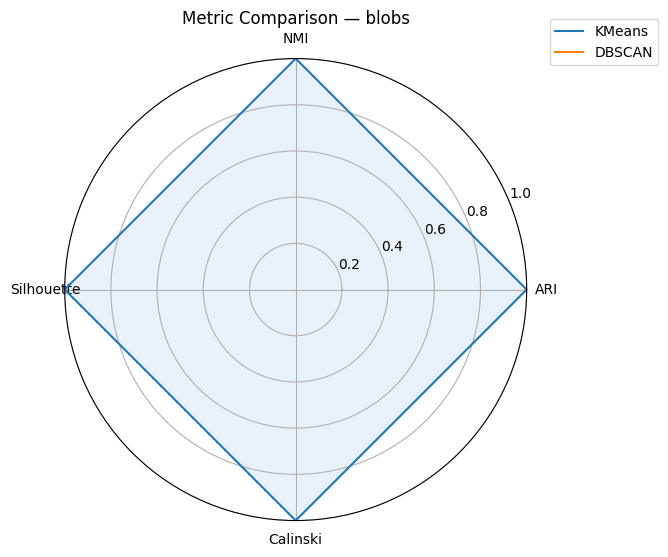

In [2]:
# ==============================================================
#  Step 6: Radar Chart Comparison
# ==============================================================

def plot_radar(metrics_km, metrics_db, dataset_name):
    labels = ["ARI", "NMI", "Silhouette", "Calinski"]
    km_values = [metrics_km[k] for k in labels]
    db_values = [metrics_db[k] for k in labels]
    
    # Normalize
    all_vals = np.array([km_values, db_values])
    min_vals = np.nanmin(all_vals, axis=0)
    max_vals = np.nanmax(all_vals, axis=0)
    norm_vals = (all_vals - min_vals) / (max_vals - min_vals + 1e-8)
    
    angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(6,6), subplot_kw=dict(polar=True))
    for i, (vals, label) in enumerate(zip(norm_vals, ["KMeans", "DBSCAN"])):
        vals = np.append(vals, vals[0])
        ax.plot(angles, vals, label=label)
        ax.fill(angles, vals, alpha=0.1)
    ax.set_thetagrids(np.degrees(angles[:-1]), labels)
    ax.set_ylim(0, 1)
    ax.set_title(f"Metric Comparison — {dataset_name}")
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.show()

for r in results:
    plot_radar(r["km_metrics"], r["db_metrics"], r["dataset"])


## **Radar Charts Summary**

* **Moons:** DBSCAN’s polygon dominates — best for *non-linear* clusters.
* **Circles:** DBSCAN edges ahead in ARI/NMI but needs tuning to avoid fragmentation.
* **Blobs:** KMeans polygon covers nearly the entire radar space — ideal for *spherical clusters*.


## **Overall Insights**

| Dataset     | Best Algorithm     | Reason                                             |
| ----------- | ------------------ | ---------------------------------------------------- |
| **Moons**   | **DBSCAN**         | Captures non-linear boundaries perfectly.            |
| **Circles** | **DBSCAN (tuned)** | Handles concentric patterns; needs better eps.       |
| **Blobs**   | **KMeans**         | Fits spherical, well-separated clusters efficiently. |


### **Conclusion**

* **KMeans**: Works best on well-separated, convex, Gaussian-like clusters.
* **DBSCAN**: Excels on non-linear, arbitrary-shaped clusters and can detect noise.
* **PCA Visualization** confirms DBSCAN’s flexibility vs KMeans’ rigidity.
* **Radar Charts** clearly highlight dataset-specific algorithm strengths.
